### 🧠 What is Self-Reflection in RAG?
Self-reflection = LLM evaluates its own output:
“Is this clear, complete, and accurate?”

#### Self-Reflection in RAG using LangGraph, we’ll design a workflow where the agent:

1. Generates an initial answer using retrieved context
2. Reflects on that answer with a dedicated self-critic LLM step
3. If unsatisfied, it can revise the query, retrieve again, or regenerate the answer

In [27]:
import os
from typing import List
from pydantic import BaseModel
from langchain_openai import OpenAIEmbeddings
from langchain_classic.schema import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langgraph.graph import StateGraph, END,START

In [28]:
from langchain_ollama import ChatOllama,OllamaEmbeddings
llm=ChatOllama(model="llama3.2:latest")
embeddings=OllamaEmbeddings(model="llama3.2:latest")

In [29]:
docs = TextLoader("sample_docs.txt").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever()

In [30]:
class RAGReflectionState(BaseModel):
    question: str
    retrieved_docs: List[Document]=[]
    answer: str=""
    reflection: str=""
    revised:bool=False
    attempts:int=0

    

In [31]:
# -------------------------
# 3. Nodes
# -------------------------

# a. Retrieve
def retrieve_docs(state: RAGReflectionState) -> RAGReflectionState:
    docs = retriever.invoke(state.question)
    return state.model_copy(update={"retrieved_docs": docs})

# b. Generate Answer
def generate_answer(state: RAGReflectionState) -> RAGReflectionState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": answer, "attempts": state.attempts + 1})

In [32]:
# c. Self-Reflect
def reflect_on_answer(state: RAGReflectionState) -> RAGReflectionState:
    
    prompt = f"""
Reflect on the following answer to see if it fully addresses the question. 
State YES if it is complete and correct, or NO with an explanation.

Question: {state.question}

Answer: {state.answer}

Respond like:
Reflection: YES or NO
Explanation: ...
"""
    result = llm.invoke(prompt).content
    is_ok = "reflection: yes" in result.lower()
    return state.model_copy(update={"reflection": result, "revised": not is_ok})

In [33]:
def finalize(state: RAGReflectionState) -> RAGReflectionState:
    return state

## Graph


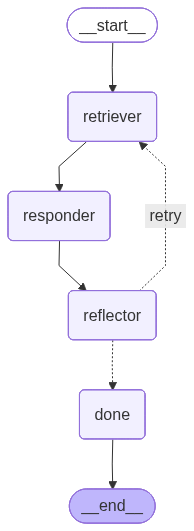

In [34]:
builder = StateGraph(RAGReflectionState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)
builder.add_node("done", finalize)

builder.set_entry_point("retriever")

builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")
# builder.add_conditional_edges(
#     "reflector",
#     lambda s: "done" if not s.revised or s.attempts >= 2 else "retriever"
# )
builder.add_conditional_edges(
    "reflector",
    lambda s: "done" if (not s.revised or s.attempts >= 2) else "retry",
    {
        "done": "done",
        "retry": "retriever"
    }
)
builder.add_edge("done", END)
graph = builder.compile()
graph


In [35]:
# -------------------------
# 5. Run the Agent
# -------------------------
if __name__ == "__main__":
    user_query = "What are the transformer variants in production deployments?"
    init_state = RAGReflectionState(question=user_query)
    result = graph.invoke(init_state)

    print("\n🧠 Final Answer:\n", result["answer"])
    print("\n🔁 Reflection Log:\n", result["reflection"])
    print("🔄 Total Attempts:", result["attempts"])


🧠 Final Answer:
 I'm not aware of any information about transformer variants being used in production deployments within the provided context. The context discusses agent loops, agent-based architectures, and the importance of feedback loops for autonomous systems, but it does not mention transformer models or their deployment.

Transformer models are a type of neural network architecture that have gained popularity in natural language processing tasks, but there is no clear connection between transformers and the context provided about agent loops. If you could provide more information or clarify the relationship between the two, I would be happy to try and assist you further.

🔁 Reflection Log:
 Reflection: YES

Explanation: The response fully addresses the question by indicating that there is no clear connection between transformer variants being used in production deployments within the provided context about agent loops and autonomous systems. It also acknowledges a lack of infor